In [28]:
!pip install tensorflow matplotlib tensorflow_io pydub  pandas numpy

In [29]:
import os
from matplotlib import pyplot as plt
import tensorflow as tf 
import tensorflow_io as tfio
import pandas as pd
import numpy as np

In [30]:
CAPUCHIN_FILE = os.path.join('/Users','raihera','project','whistles', 'yes', 'XC3776-0.wav')
NOT_CAPUCHIN_FILE = os.path.join('/Users','raihera','project','whistles', 'no', 'afternoon-birds-song-in-forest-0.wav')

In [31]:
def load_wav_16k_mono(filename):
    # Load encoded wav file
    file_contents = tf.io.read_file(filename)
    # Decode wav (tensors by channels) 
    wav, sample_rate = tf.audio.decode_wav(file_contents, desired_channels=1)
    # Removes trailing axis
    wav = tf.squeeze(wav, axis=-1)
    sample_rate = tf.cast(sample_rate, dtype=tf.int64)
    # Goes from 44100Hz to 16000hz - amplitude of the audio signal
    wav = tfio.audio.resample(wav, rate_in=sample_rate, rate_out=16000)
    return wav

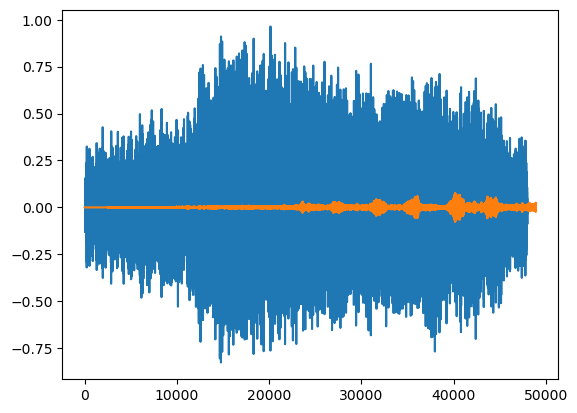

In [32]:
wave = load_wav_16k_mono(CAPUCHIN_FILE)
nowave = load_wav_16k_mono(NOT_CAPUCHIN_FILE)
plt.plot(wave)
plt.plot(nowave)
plt.show()

In [63]:
POS = os.path.join('/Users','raihera','project','whistles', 'yes')
NEG = os.path.join('/Users','raihera','project','whistles', 'no')

In [64]:
lengths = []
for file in os.listdir(POS):
    if file.endswith('.wav'):
        tensor_wave = load_wav_16k_mono(os.path.join('/Users','raihera','project','whistles', 'yes', file))
        lengths.append(len(tensor_wave))

In [65]:
lengths

[49868, 22056, 121272, 15216, 199476, 80470, 47602, 29916, 49202]

In [66]:
tf.math.reduce_mean(lengths)

<tf.Tensor: shape=(), dtype=int32, numpy=68342>

In [67]:
48000/16000

3.0

In [71]:
tf.math.reduce_max(lengths)


<tf.Tensor: shape=(), dtype=int32, numpy=199476>

In [72]:
pos = tf.data.Dataset.list_files(POS+'/*.wav')
neg = tf.data.Dataset.list_files(NEG+'/*.wav')

In [79]:
positives = tf.data.Dataset.zip((pos, tf.data.Dataset.from_tensor_slices(tf.ones(len(pos)))))
negatives = tf.data.Dataset.zip((neg, tf.data.Dataset.from_tensor_slices(tf.zeros(len(neg)))))
data = positives.concatenate(negatives)

In [82]:
len(data)

40

In [83]:
def preprocess(file_path, label): 
    wav = load_wav_16k_mono(file_path)
    wav = wav[:48000]
    zero_padding = tf.zeros([48000] - tf.shape(wav), dtype=tf.float32)
    wav = tf.concat([zero_padding, wav],0)
    spectrogram = tf.signal.stft(wav, frame_length=320, frame_step=32)
    spectrogram = tf.abs(spectrogram)
    spectrogram = tf.expand_dims(spectrogram, axis=2)
    return spectrogram, label

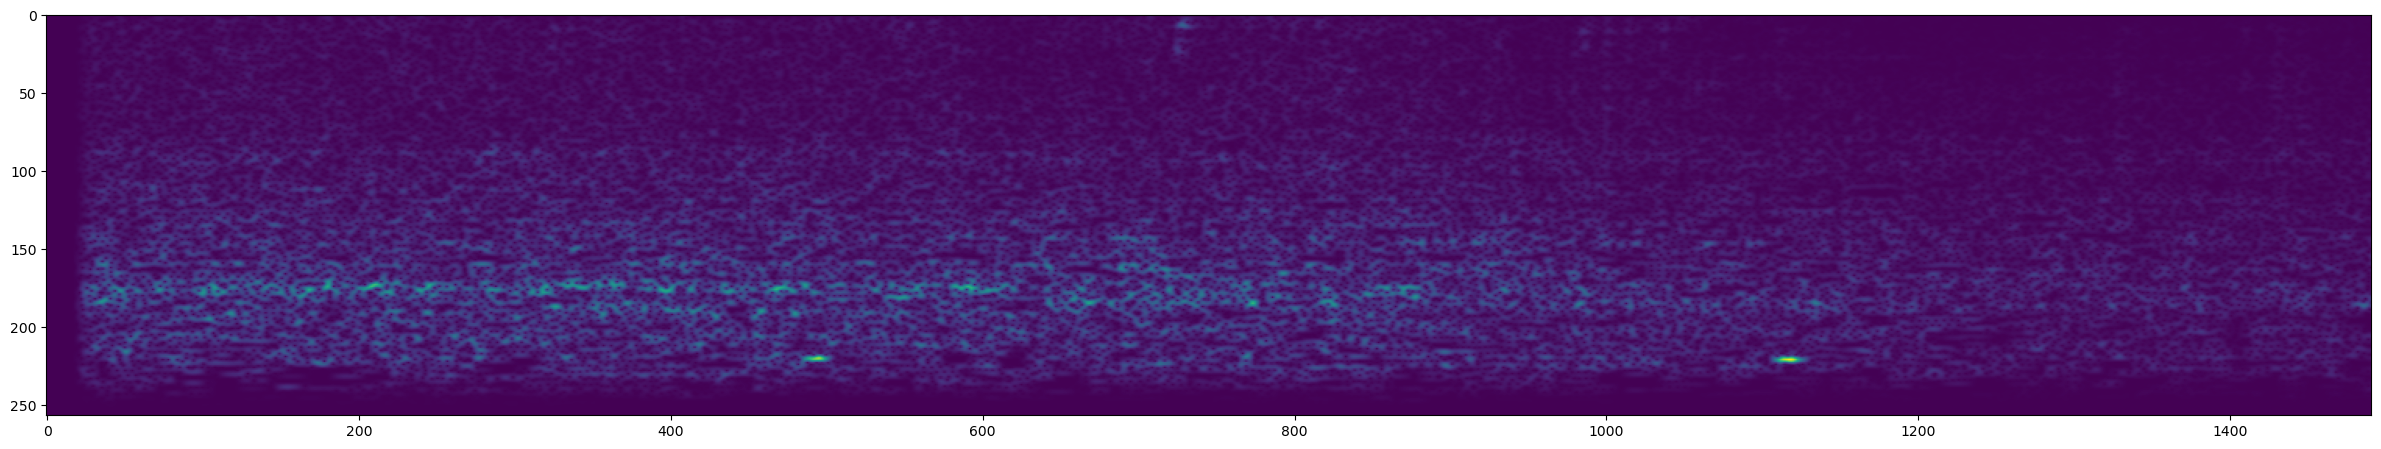

In [84]:
filepath, label = positives.shuffle(buffer_size=10000).as_numpy_iterator().next()
spectrogram, label = preprocess(filepath, label)
plt.figure(figsize=(30,20))
plt.imshow(tf.transpose(spectrogram)[0])
plt.show()

In [85]:
spectrogram

<tf.Tensor: shape=(1491, 257, 1), dtype=float32, numpy=
array([[[1.89779879e-04],
        [1.64868761e-04],
        [1.08409266e-04],
        ...,
        [2.67087057e-06],
        [1.55345310e-06],
        [4.72435204e-07]],

       [[4.09107190e-04],
        [3.66957014e-04],
        [2.79538392e-04],
        ...,
        [4.59129478e-06],
        [2.80943846e-06],
        [1.23980863e-06]],

       [[7.26842438e-04],
        [6.54576404e-04],
        [4.96215071e-04],
        ...,
        [5.83086785e-06],
        [3.29387399e-06],
        [2.13831663e-06]],

       ...,

       [[7.00853765e-04],
        [2.27854066e-02],
        [7.87086114e-02],
        ...,
        [1.01573288e-03],
        [2.95089616e-04],
        [2.20932066e-04]],

       [[5.39362431e-04],
        [2.22236533e-02],
        [7.91276619e-02],
        ...,
        [1.08936068e-03],
        [1.85524943e-04],
        [2.24858522e-04]],

       [[1.32182240e-03],
        [2.67800782e-02],
        [7.33938292e-02]

In [90]:
data = data.map(preprocess)
data = data.cache()
data = data.shuffle(buffer_size=1000)
data = data.batch(16)
data = data.prefetch(8)

TypeError: in user code:

    File "/var/folders/pd/11gf3dts50j2ngtmplbp5n7m0000gr/T/ipykernel_25862/3763039504.py", line 2, in preprocess  *
        wav = load_wav_16k_mono(file_path)
    File "/var/folders/pd/11gf3dts50j2ngtmplbp5n7m0000gr/T/ipykernel_25862/3394082463.py", line 3, in load_wav_16k_mono  *
        file_contents = tf.io.read_file(filename)

    TypeError: Input 'filename' of 'ReadFile' Op has type float32 that does not match expected type of string.


In [88]:
len(data)

3

In [57]:
trainLength = len(data)
print(trainLength)
train = data.take(1)
test = data.skip(1).take(15)

1


In [58]:
samples, labels = train.as_numpy_iterator().next()
samples.shape

(2, 1491, 257, 1)

In [59]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Dense, Flatten

In [60]:
model = Sequential()
model.add(Conv2D(16, (3,3), activation='relu', input_shape=(1491, 257,1)))
model.add(Conv2D(16, (3,3), activation='relu'))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [61]:
model.compile('Adam', loss='BinaryCrossentropy', metrics=[tf.keras.metrics.Recall(),tf.keras.metrics.Precision()])
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 1489, 255, 16)     160       
                                                                 
 conv2d_3 (Conv2D)           (None, 1487, 253, 16)     2320      
                                                                 
 flatten_1 (Flatten)         (None, 6019376)           0         
                                                                 
 dense_2 (Dense)             (None, 128)               770480256 
                                                                 
 dense_3 (Dense)             (None, 1)                 129       
                                                                 
Total params: 770482865 (2.87 GB)
Trainable params: 770482865 (2.87 GB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [62]:
hist = model.fit(train, epochs=4, validation_data=test)

Epoch 1/4
1/1 [==============================] - ETA: 0s - loss: 0.7632 - recall_1: 0.0000e+00 - precision_1: 0.0000e+00

ValueError: Expected input data to be non-empty.